In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

In [4]:
df2yr=pd.read_csv('dataset/cme_events_2year.csv')
df2yr

,event_id,catalog,start_time,source_location,note,cme_type,speed,speed_unit,direction,half_angle,...,linked_events,date,year,month,day,hour,day_of_year,quarter,speed_category,potentially_geoeffective
0,2023-07-26T11:12:00-CME-001,M2M_CATALOG,2023-07-26 11:12:00+00:00,N23W77,Outflow-like narrow CME seen to the west in SO...,NaN,345.0,km/s,NaN,10.0,...,NaN,2023-07-26,2023,7,26,11,207,3,Normal,False
1,2023-07-27T21:36:00-CME-001,M2M_CATALOG,2023-07-27 21:36:00+00:00,NaN,Source is rising loops and widely opening fiel...,NaN,680.0,km/s,NaN,51.0,...,NaN,2023-07-27,2023,7,27,21,208,3,Fast,False
2,2023-07-27T23:24:00-CME-001,M2M_CATALOG,2023-07-27 23:24:00+00:00,S25E75,Possible CME associated with the M-class flare...,NaN,590.0,km/s,NaN,31.0,...,2023-07-27T22:04:00-FLR-001,2023-07-27,2023,7,27,23,208,3,Fast,False
3,2023-07-28T15:53:00-CME-001,M2M_CATALOG,2023-07-28 15:53:00+00:00,N25W99,Fast CME in the NW following the associated M-...,NaN,2000.0,km/s,NaN,43.0,...,"2023-07-28T15:39:00-FLR-001, 2023-07-28T18:12:...",2023-07-28,2023,7,28,15,209,3,Extreme,True
4,2023-07-28T22:36:00-CME-001,M2M_CATALOG,2023-07-28 22:36:00+00:00,N25E25,Asymmetric partial halo CME seen directed prim...,NaN,589.0,km/s,NaN,42.0,...,"2023-08-01T06:00:00-IPS-001, 2023-08-01T10:08:...",2023-07-28,2023,7,28,22,209,3,Fast,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2846,2025-07-13T22:12:00-CME-001,M2M_CATALOG,2025-07-13 22:12:00+00:00,N18W72,CME first seen to the WNW in SOHO LASCO C2 sta...,NaN,474.0,km/s,NaN,25.0,...,NaN,2025-07-13,2025,7,13,22,194,3,Normal,False
2847,2025-07-14T01:25:00-CME-001,M2M_CATALOG,2025-07-14 01:25:00+00:00,NaN,CME seen to the SE in SOHO LASCO C2/C3 and GOE...,NaN,514.0,km/s,NaN,21.0,...,NaN,2025-07-14,2025,7,14,1,195,3,Fast,False
2848,2025-07-14T03:36:00-CME-001,M2M_CATALOG,2025-07-14 03:36:00+00:00,NaN,Faint flux rope CME seen to the NW in SOHO LAS...,NaN,390.0,km/s,NaN,26.0,...,NaN,2025-07-14,2025,7,14,3,195,3,Normal,False
2849,2025-07-14T14:36:00-CME-001,M2M_CATALOG,2025-07-14 14:36:00+00:00,NaN,"CME seen to the SW in SOHO LASCO C2/C3, STEREO...",NaN,358.0,km/s,NaN,42.0,...,NaN,2025-07-14,2025,7,14,14,195,3,Normal,False


In [5]:
df2yr.columns

Index(['event_id', 'catalog', 'start_time', 'source_location', 'note',
       'cme_type', 'speed', 'speed_unit', 'direction', 'half_angle',
       'latitude', 'longitude', 'most_accurate', 'analysis_time',
       'level_of_data', 'analysis_type', 'measurement_pa',
       'measurement_technique', 'instruments', 'linked_events', 'date', 'year',
       'month', 'day', 'hour', 'day_of_year', 'quarter', 'speed_category',
       'potentially_geoeffective'],
      dtype='str')

In [7]:
df2yr.isnull().sum()

event_id                       0
catalog                        0
start_time                     0
source_location             1674
note                           0
cme_type                    2851
speed                          0
speed_unit                     0
direction                   2851
half_angle                     0
latitude                       0
longitude                      0
most_accurate                  0
analysis_time                  0
level_of_data                  0
analysis_type                  0
measurement_pa              2851
measurement_technique          0
instruments                    0
linked_events               2247
date                           0
year                           0
month                          0
day                            0
hour                           0
day_of_year                    0
quarter                        0
speed_category                 0
potentially_geoeffective       0
dtype: int64

In [12]:
df2yr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2851 entries, 0 to 2850
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   event_id                  2851 non-null   str    
 1   catalog                   2851 non-null   str    
 2   start_time                2851 non-null   str    
 3   source_location           1177 non-null   str    
 4   note                      2851 non-null   str    
 5   cme_type                  0 non-null      float64
 6   speed                     2851 non-null   float64
 7   speed_unit                2851 non-null   str    
 8   direction                 0 non-null      float64
 9   half_angle                2851 non-null   float64
 10  latitude                  2851 non-null   float64
 11  longitude                 2851 non-null   float64
 12  most_accurate             2851 non-null   bool   
 13  analysis_time             2851 non-null   str    
 14  level_of_data      

In [13]:
# Drop rows with NaN values in source_location column
df2yr_clean = df2yr.dropna(subset=['source_location'])
df2yr_clean

,event_id,catalog,start_time,source_location,note,cme_type,speed,speed_unit,direction,half_angle,...,linked_events,date,year,month,day,hour,day_of_year,quarter,speed_category,potentially_geoeffective
0,2023-07-26T11:12:00-CME-001,M2M_CATALOG,2023-07-26 11:12:00+00:00,N23W77,Outflow-like narrow CME seen to the west in SO...,NaN,345.0,km/s,NaN,10.0,...,NaN,2023-07-26,2023,7,26,11,207,3,Normal,False
2,2023-07-27T23:24:00-CME-001,M2M_CATALOG,2023-07-27 23:24:00+00:00,S25E75,Possible CME associated with the M-class flare...,NaN,590.0,km/s,NaN,31.0,...,2023-07-27T22:04:00-FLR-001,2023-07-27,2023,7,27,23,208,3,Fast,False
3,2023-07-28T15:53:00-CME-001,M2M_CATALOG,2023-07-28 15:53:00+00:00,N25W99,Fast CME in the NW following the associated M-...,NaN,2000.0,km/s,NaN,43.0,...,"2023-07-28T15:39:00-FLR-001, 2023-07-28T18:12:...",2023-07-28,2023,7,28,15,209,3,Extreme,True
4,2023-07-28T22:36:00-CME-001,M2M_CATALOG,2023-07-28 22:36:00+00:00,N25E25,Asymmetric partial halo CME seen directed prim...,NaN,589.0,km/s,NaN,42.0,...,"2023-08-01T06:00:00-IPS-001, 2023-08-01T10:08:...",2023-07-28,2023,7,28,22,209,3,Fast,False
5,2023-07-29T07:53:00-CME-001,M2M_CATALOG,2023-07-29 07:53:00+00:00,N15E90,CME visible in the NE of SOHO LASCO C2/C3 and ...,NaN,526.0,km/s,NaN,32.0,...,2023-07-29T06:55:00-FLR-001,2023-07-29,2023,7,29,7,210,3,Fast,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,2025-07-12T04:12:00-CME-001,M2M_CATALOG,2025-07-12 04:12:00+00:00,N32W23,Faint CME to the NW seen in SOHO LASCO C2 and ...,NaN,308.0,km/s,NaN,23.0,...,NaN,2025-07-12,2025,7,12,4,193,3,Normal,False
2839,2025-07-12T08:00:00-CME-001,M2M_CATALOG,2025-07-12 08:00:00+00:00,S35W60,A relatively narrow CME with a messy front vis...,NaN,595.0,km/s,NaN,21.0,...,NaN,2025-07-12,2025,7,12,8,193,3,Fast,False
2840,2025-07-12T15:12:00-CME-001,M2M_CATALOG,2025-07-12 15:12:00+00:00,S21W95,Faint CME with fuzzy front seen to the SW in S...,NaN,218.0,km/s,NaN,40.0,...,NaN,2025-07-12,2025,7,12,15,193,3,Slow,False
2841,2025-07-12T15:36:00-CME-001,M2M_CATALOG,2025-07-12 15:36:00+00:00,N20E52,Fast CME seen to the NE in SOHO LASCO and GOES...,NaN,924.0,km/s,NaN,20.0,...,NaN,2025-07-12,2025,7,12,15,193,3,Fast,True


<Figure size 1200x600 with 0 Axes>

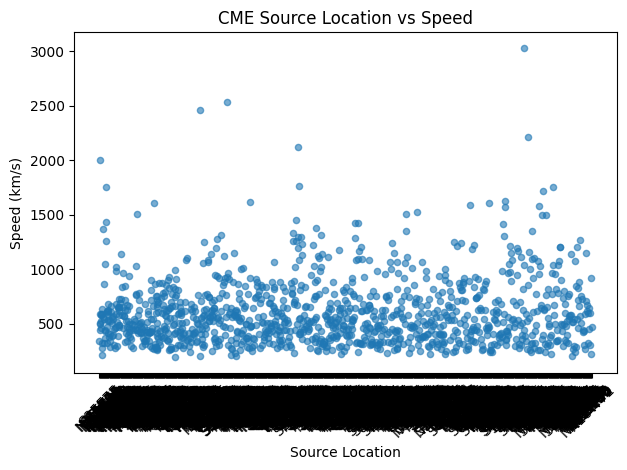

In [14]:
import matplotlib.pyplot as plt

# Create a scatter plot of source_location vs speed
plt.figure(figsize=(12, 6))
df2yr_clean.plot(kind='scatter', x='source_location', y='speed', alpha=0.6)
plt.xlabel('Source Location')
plt.ylabel('Speed (km/s)')
plt.title('CME Source Location vs Speed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np

# Sample dataset (replace with your CSV later)
df = pd.DataFrame({
    "begin_time": pd.date_range(start="2024-01-01", periods=200, freq="H"),
    "event_type": ["Flare", "Storm", "CME", "Flare", "Storm"] * 40,
    "intensity": np.random.randint(1, 100, 200)
})

df["hour"] = df["begin_time"].dt.hour

C:\Users\Ritik singh\AppData\Local\Temp\ipykernel_50516\499651350.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "begin_time": pd.date_range(start="2024-01-01", periods=200, freq="H"),


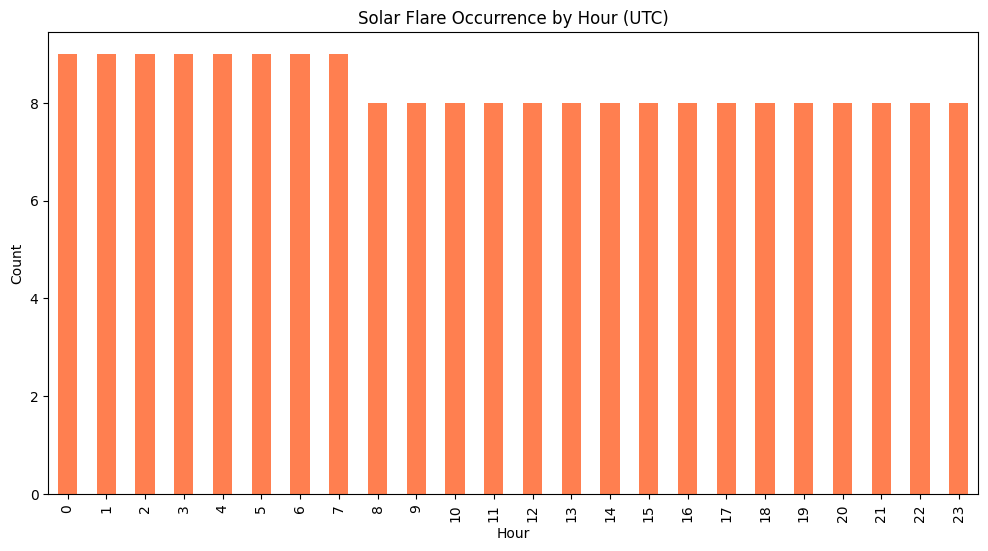

In [2]:
import matplotlib.pyplot as plt

hourly_dist = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12,6))
hourly_dist.plot(kind='bar', color='coral')
plt.title('Solar Flare Occurrence by Hour (UTC)')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

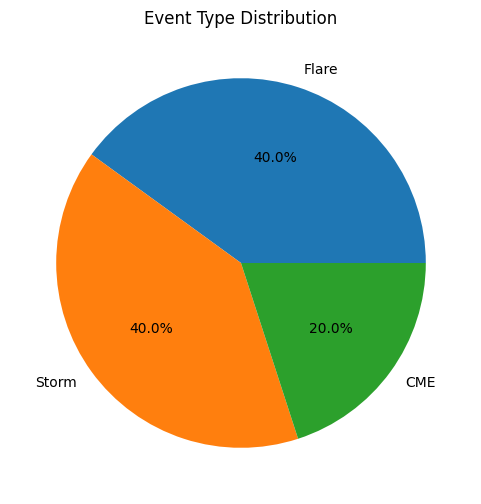

In [4]:
event_counts = df["event_type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%')
plt.title('Event Type Distribution')
plt.show()

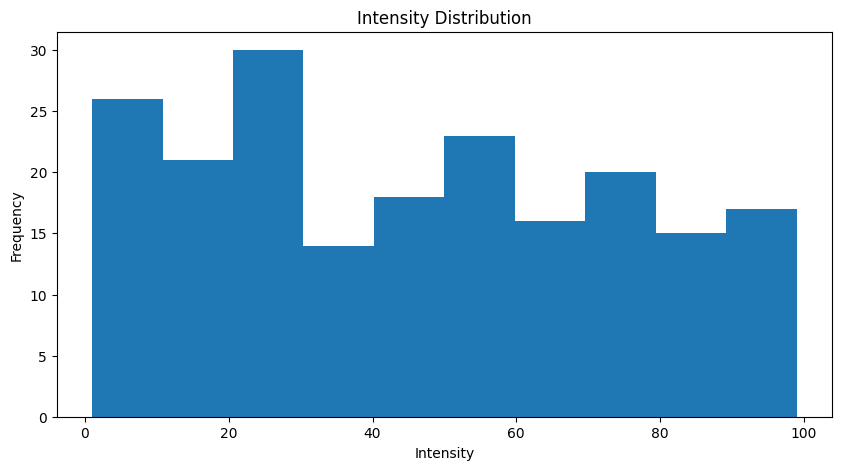

In [5]:
plt.figure(figsize=(10,5))
plt.hist(df["intensity"], bins=10)
plt.title('Intensity Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

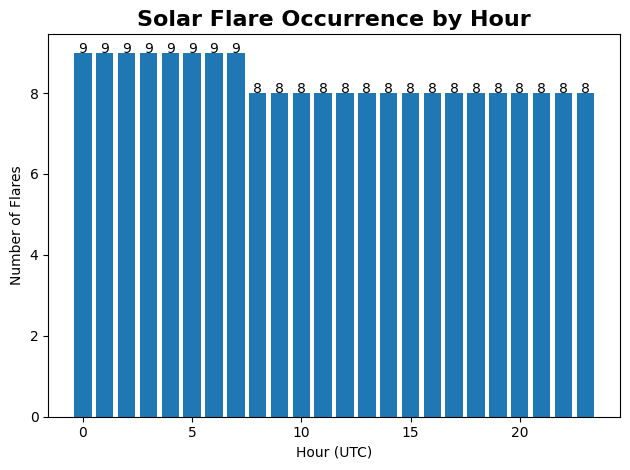

In [7]:
hourly_dist = df["hour"].value_counts().sort_index()

plt.figure()
bars = plt.bar(hourly_dist.index, hourly_dist.values)

plt.title("Solar Flare Occurrence by Hour", fontsize=16, weight='bold')
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Flares")

# value labels
for bar in bars:
    plt.text(bar.get_x() + 0.2, bar.get_height(), str(int(bar.get_height())))

plt.tight_layout()
plt.show()

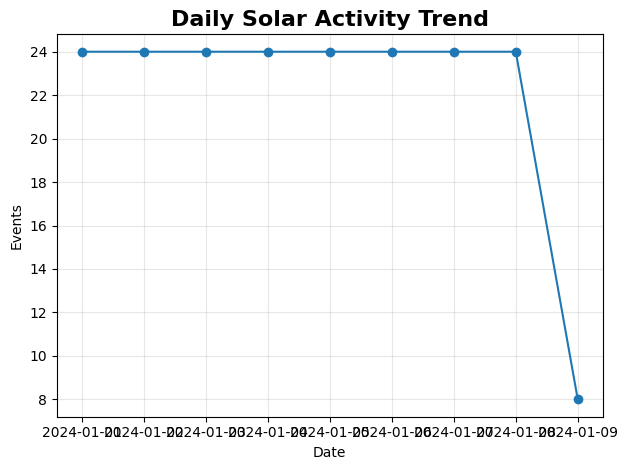

In [8]:
daily = df.set_index("begin_time").resample("D").size()

plt.figure()
plt.plot(daily.index, daily.values, marker='o')

plt.title("Daily Solar Activity Trend", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Events")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

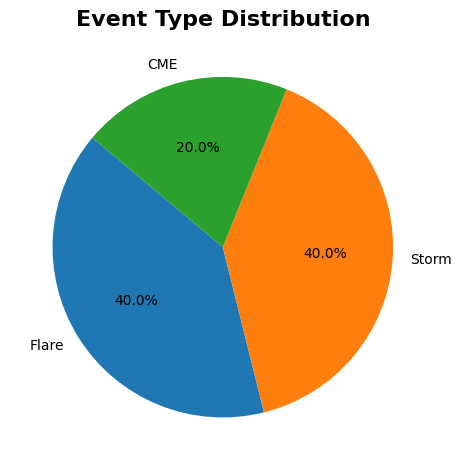

In [9]:
event_counts = df["event_type"].value_counts()

plt.figure()
plt.pie(event_counts,
        labels=event_counts.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title("Event Type Distribution", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

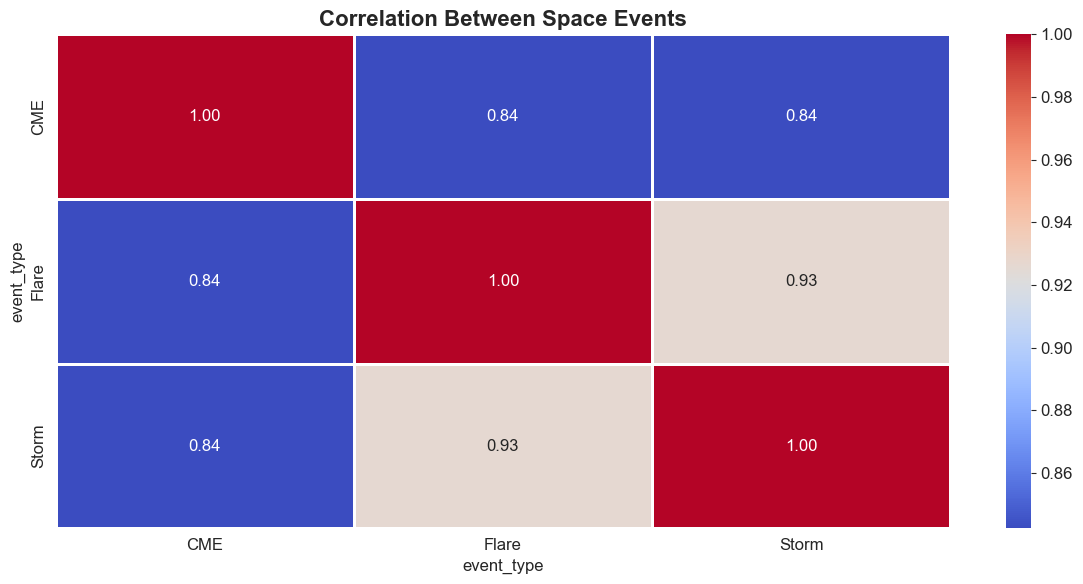

In [13]:
event_daily = df.set_index("begin_time").groupby([
    pd.Grouper(freq='D'), "event_type"
]).size().unstack(fill_value=0)

corr = event_daily.corr()

plt.figure()
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            fmt=".2f")

plt.title("Correlation Between Space Events", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

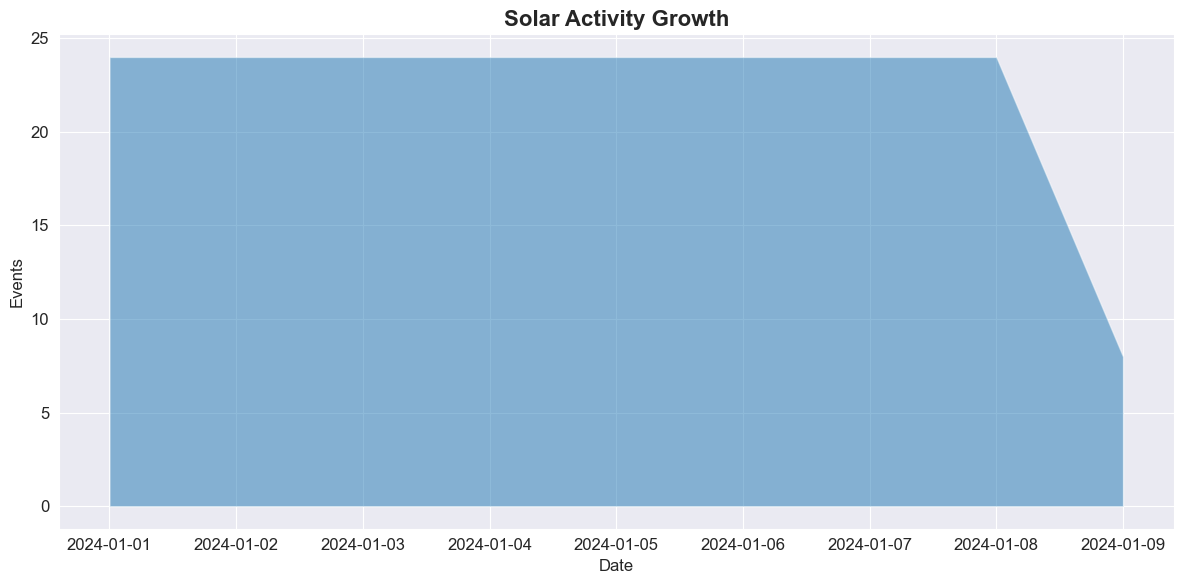

In [14]:
daily = df.set_index("begin_time").resample("D").size()

plt.figure()
plt.fill_between(daily.index, daily.values, alpha=0.5)

plt.title("Solar Activity Growth", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Events")

plt.tight_layout()
plt.show()

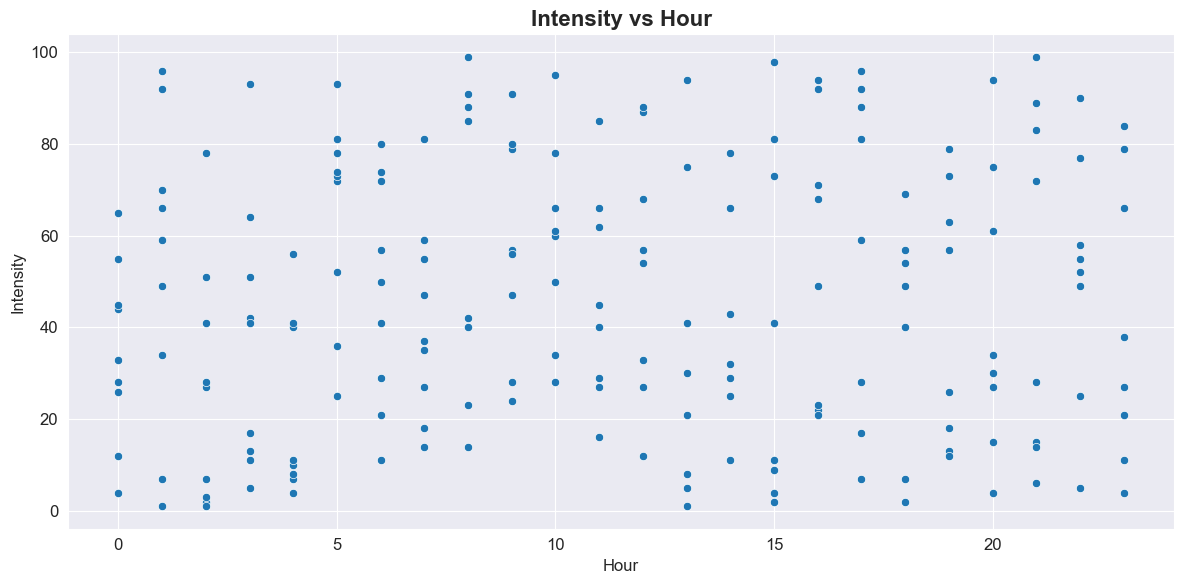

In [15]:
plt.figure()
sns.scatterplot(x=df["hour"], y=df["intensity"])

plt.title("Intensity vs Hour", fontsize=16, weight='bold')
plt.xlabel("Hour")
plt.ylabel("Intensity")

plt.tight_layout()
plt.show()

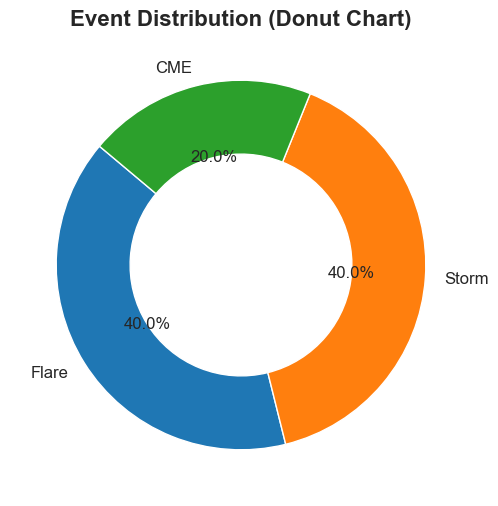

In [16]:
import matplotlib.pyplot as plt

event_counts = df["event_type"].value_counts()

plt.figure(figsize=(6,6))

# Donut
plt.pie(event_counts,
        labels=event_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'width':0.4})  # 🔥 donut banata hai

plt.title("Event Distribution (Donut Chart)", fontsize=16, weight='bold')

plt.show()

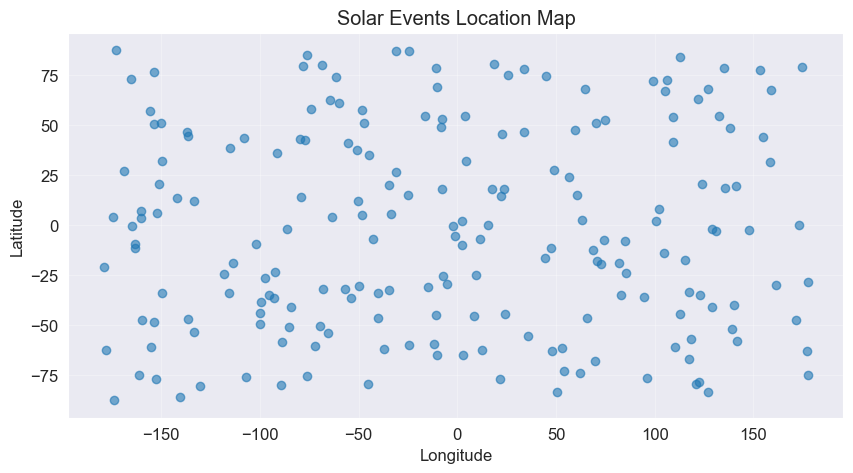

In [17]:
import matplotlib.pyplot as plt

# Example dummy location data (replace with real)
df["lat"] = np.random.uniform(-90, 90, len(df))
df["lon"] = np.random.uniform(-180, 180, len(df))

plt.figure(figsize=(10,5))

plt.scatter(df["lon"], df["lat"], alpha=0.6)

plt.title("Solar Events Location Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(alpha=0.3)
plt.show()

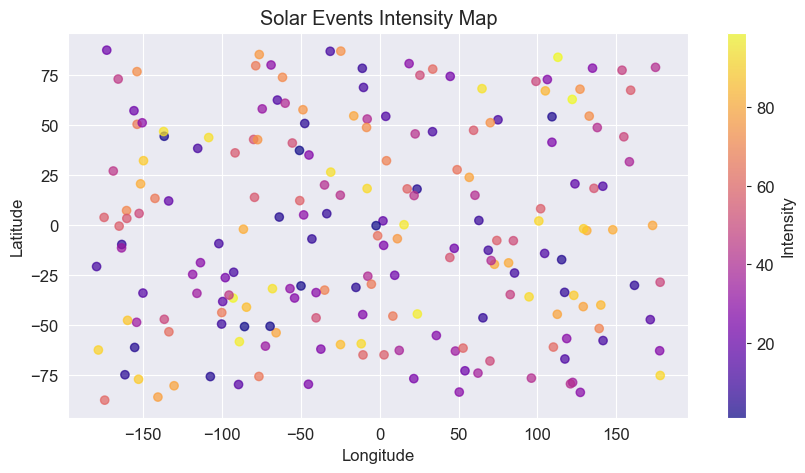

In [18]:
plt.figure(figsize=(10,5))

plt.scatter(df["lon"], df["lat"],
            c=df["intensity"],
            cmap='plasma',
            alpha=0.7)

plt.colorbar(label="Intensity")

plt.title("Solar Events Intensity Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

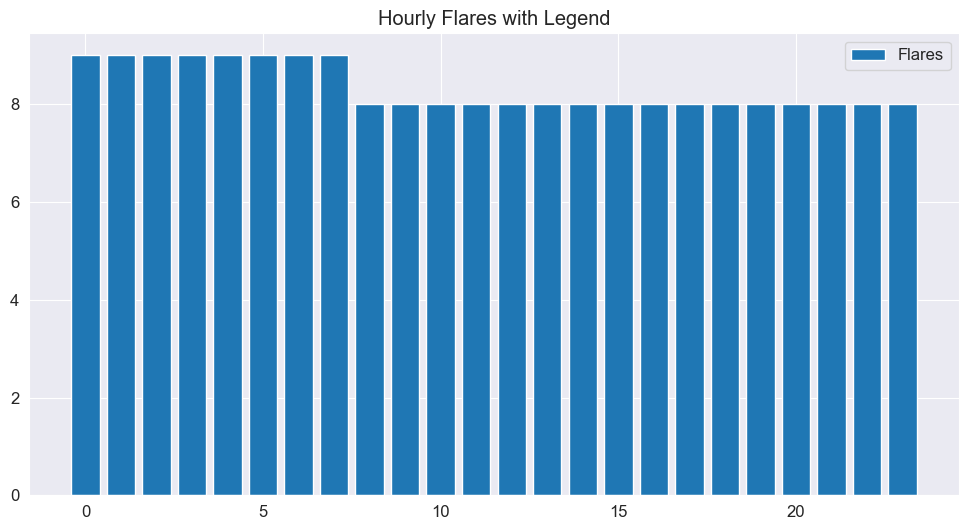

In [19]:
hourly_dist = df["hour"].value_counts().sort_index()

plt.figure()
plt.bar(hourly_dist.index, hourly_dist.values, label="Flares")

plt.legend()
plt.title("Hourly Flares with Legend")

plt.show()

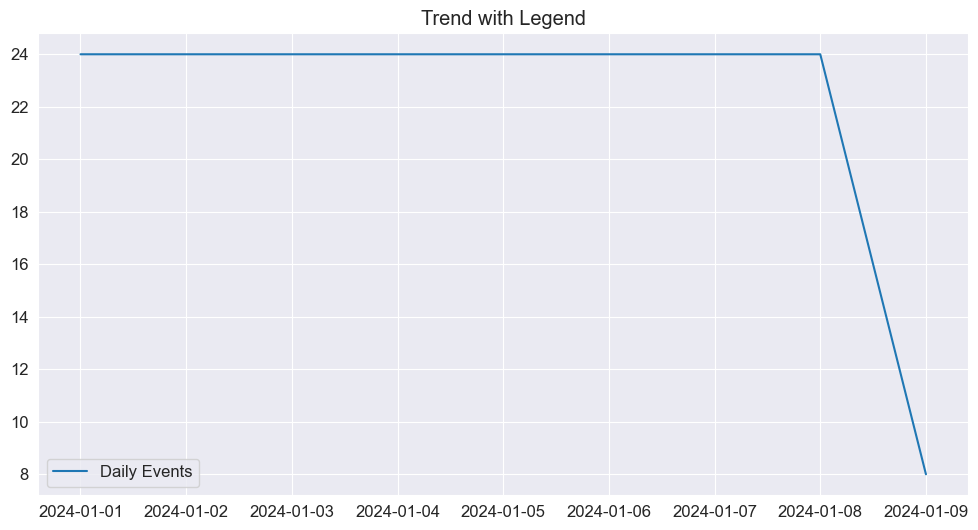

In [20]:
daily = df.set_index("begin_time").resample("D").size()

plt.figure()
plt.plot(daily.index, daily.values, label="Daily Events")

plt.legend()
plt.title("Trend with Legend")

plt.show()

In [4]:
import pandas as pd
import numpy as np

# Dummy dataset (for testing)
df = pd.DataFrame({
    "begin_time": pd.date_range(start="2024-01-01", periods=200, freq="h"),
    "event_type": ["Flare", "Storm", "CME", "Flare", "Storm"] * 40,
    "intensity": np.random.randint(1, 100, 200)
})

# Extra columns
df["hour"] = df["begin_time"].dt.hour

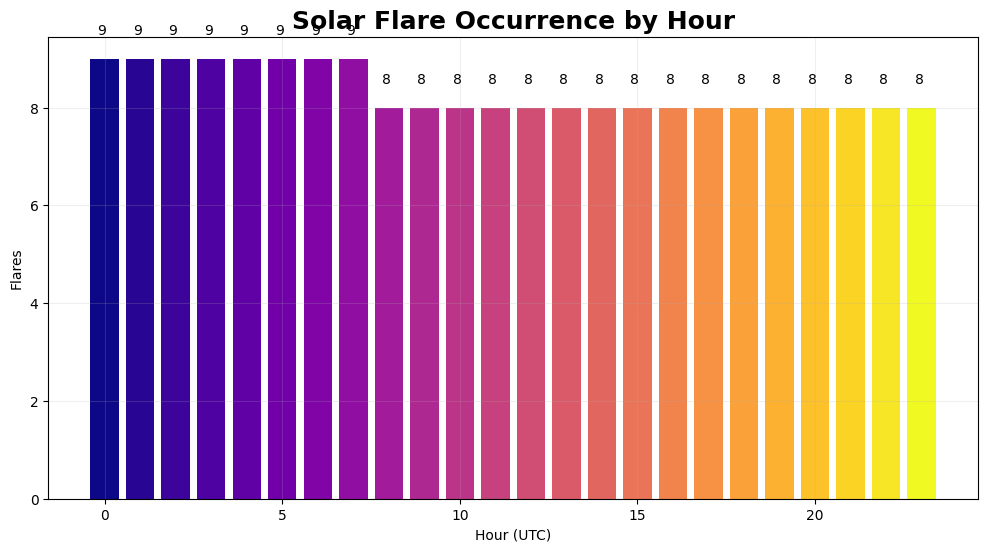

In [7]:

import matplotlib.pyplot as plt
import numpy as np

hourly_dist = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12,6))

colors = plt.cm.plasma(np.linspace(0,1,len(hourly_dist)))

bars = plt.bar(hourly_dist.index, hourly_dist.values, color=colors)

plt.title("Solar Flare Occurrence by Hour", fontsize=18, weight='bold')
plt.xlabel("Hour (UTC)")
plt.ylabel("Flares")

# value labels
for bar in bars:
    plt.text(bar.get_x() + 0.2, bar.get_height()+0.5, int(bar.get_height()))

plt.grid(alpha=0.2)
plt.show()

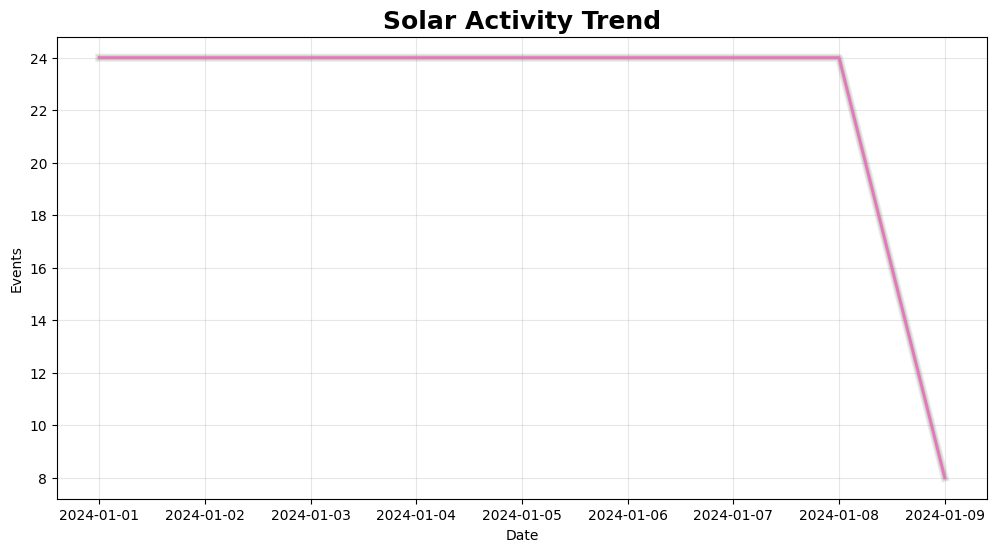

In [8]:
daily = df.set_index("begin_time").resample("D").size()

plt.figure(figsize=(12,6))

# glow effect
for i in range(6,0,-1):
    plt.plot(daily.index, daily.values, linewidth=i, alpha=0.1)

plt.plot(daily.index, daily.values, linewidth=2)

plt.title("Solar Activity Trend", fontsize=18, weight='bold')
plt.xlabel("Date")
plt.ylabel("Events")

plt.grid(alpha=0.3)
plt.show()

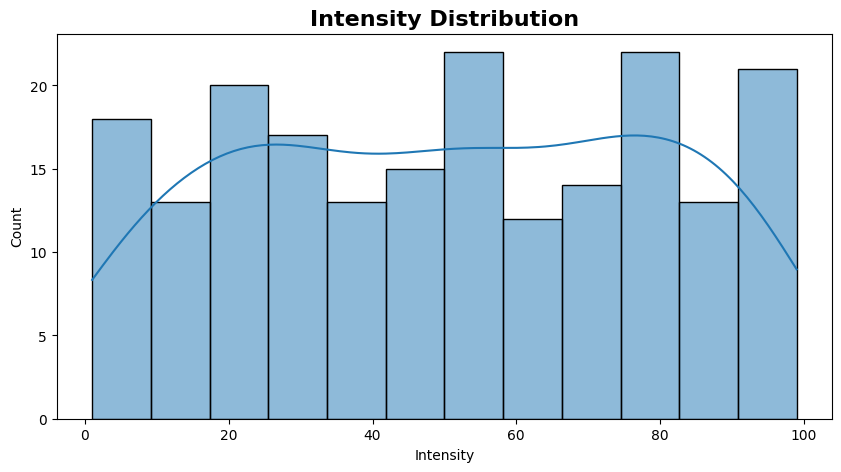

In [9]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df["intensity"], bins=12, kde=True)

plt.title("Intensity Distribution", fontsize=16, weight='bold')
plt.xlabel("Intensity")

plt.show()

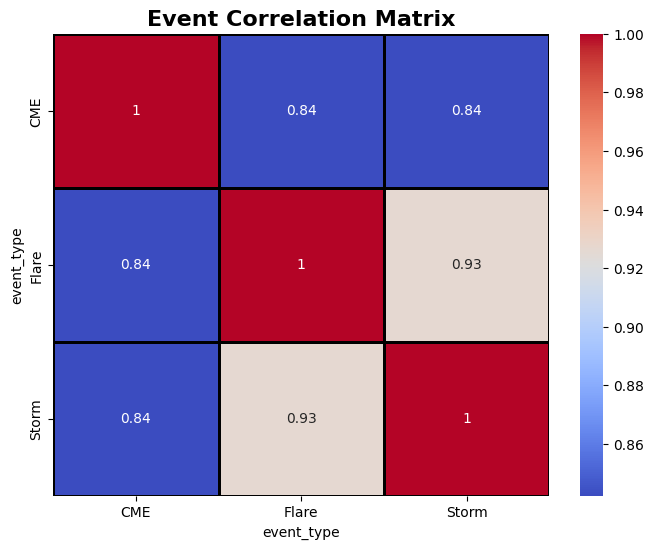

In [10]:
event_daily = df.set_index("begin_time").groupby([
    pd.Grouper(freq='D'), "event_type"
]).size().unstack(fill_value=0)

corr = event_daily.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=2,
            linecolor='black')

plt.title("Event Correlation Matrix", fontsize=16, weight='bold')
plt.show()

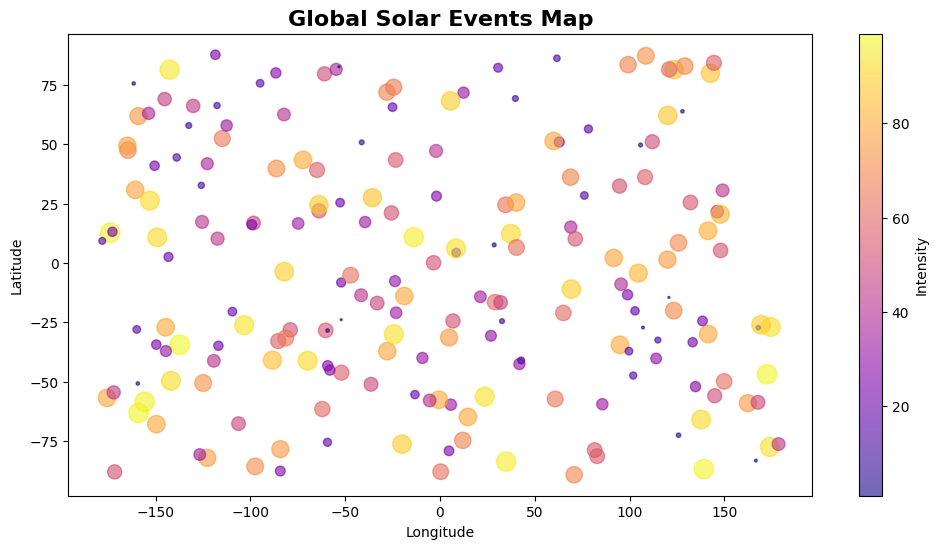

In [ ]:
df["lat"] = np.random.uniform(-90, 90, len(df))
df["lon"] = np.random.uniform(-180, 180, len(df))

plt.figure(figsize=(12,6))

plt.scatter(df["lon"], df["lat"],
            c=df["intensity"],
            s=df["intensity"]*2,
            cmap="plasma",
            alpha=0.6)


plt.colorbar(label="Intensity")

plt.title("Global Solar Events Map", fontsize=16, weight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("static/plots/map.png")
plt.close()

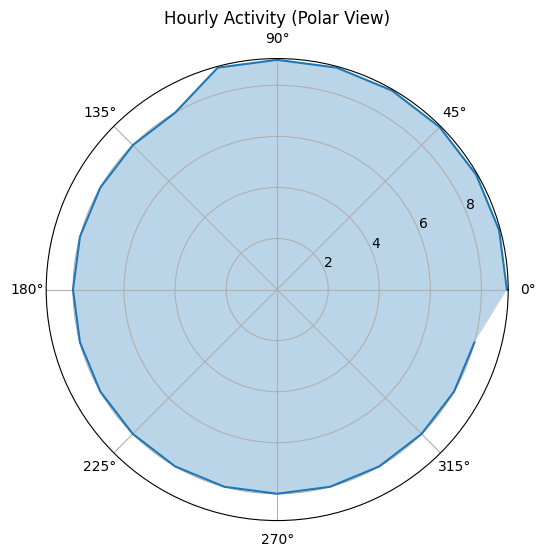

In [ ]:
import numpy as np

angles = np.linspace(0, 2*np.pi, len(df["hour"].unique()), endpoint=False)
values = df.groupby("hour").size().values

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.3)

plt.title("Hourly Activity (Polar View)")
plt.savefig("static/plots/map.png")
plt.close()

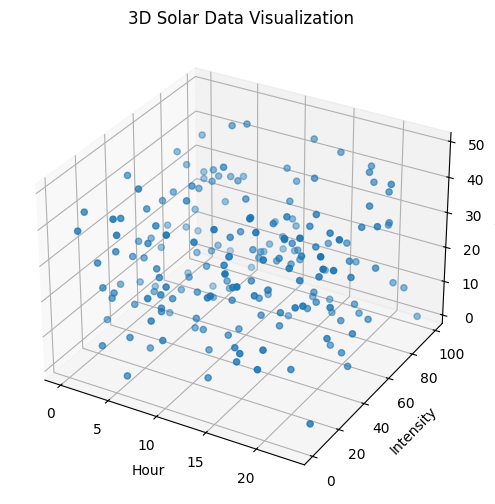

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

x = df["hour"]
y = df["intensity"]
z = np.random.randint(1,50,len(df))

ax.scatter(x, y, z)

ax.set_xlabel("Hour")
ax.set_ylabel("Intensity")
ax.set_zlabel("Value")

plt.title("3D Solar Data Visualization")
plt.show()

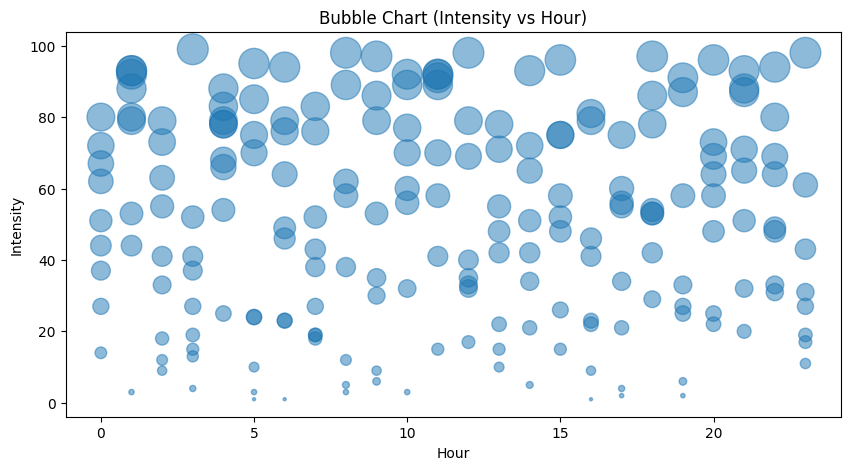

In [14]:
plt.figure(figsize=(10,5))

plt.scatter(df["hour"], df["intensity"],
            s=df["intensity"]*5,
            alpha=0.5)

plt.title("Bubble Chart (Intensity vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Intensity")

plt.show()